---
**Pipeline:** [01 Dataset] → [02 Architecture] → [03 Optimization] → [04 Training] → [05 Evaluation] → [06 Export]

**Next:** `02_model_architecture.ipynb`

---

# 🎓 Face Recognition Attendance System - Complete Training Pipeline

This notebook provides a streamlined face recognition training pipeline using **preprocessed VGGFace2 dataset** from Kaggle.

## 📋 Pipeline Overview

1. **Dataset Download** - Download preprocessed & aligned VGGFace2 dataset from Kaggle
2. **Data Split** - Create train/val split from the single dataset
3. **Model Architecture** - Build the MobileFaceNet + ArcFace model architecture
4. **Training Optimization** - Configure training parameters and optimizations
5. **Model Training** - Train the face recognition model with Drive checkpoints
6. **Model Evaluation** - Evaluate model performance on validation data
7. **Model Export** - Export the trained model for deployment

## ✨ What's New?

This notebook uses **VGGFace2 pre-aligned dataset** at 112x112 resolution:
- ✅ **No face detection/alignment needed** - Already done by opensphere!
- ✅ **Fast dataset download** - Download via kagglehub (cached)
- ✅ **Large-scale training** - 8,631 identities, 3.14M images
- ✅ **Production-ready** - Same preprocessing as research papers

**Dataset:** `yakhyokhuja/vggface2-112x112`
- Source: VGGFace2 training set (opensphere pre-aligned)
- Identities: 8,631 people
- Images: ~3.14 million faces
- Format: 112x112 RGB, already aligned & cropped
- Size: 18.69 GB
- Structure: `id_0/`, `id_1/`, ..., `id_8630/`

**Auto Train/Val Split:**
- The notebook creates a 90/10 split automatically
- Validation uses held-out identities (no data leakage)
- Ensures robust evaluation

## 💾 Google Drive Integration

**Model checkpoints** are automatically saved to Google Drive:
- ✅ Checkpoints saved every 500 steps to Drive
- ✅ Automatic resume from latest checkpoint on disconnect
- ✅ No training progress loss!

## ⚙️ Setup Instructions

1. **Enable GPU**: Runtime → Change runtime type → Hardware accelerator → GPU (T4 recommended)
2. **Mount Drive**: The notebook will prompt you to authorize Google Drive access
3. **Run All Cells**: Runtime → Run all (Kaggle credentials handled automatically by kagglehub)

## 💡 Colab Disconnect Protection

If Colab disconnects during training:
- Simply re-run the training section
- It will automatically load the latest checkpoint from Drive
- Training continues from where it stopped

## 📊 Dataset Reference

This dataset is used in production face recognition systems:
- Reference code: https://github.com/yakhyo/face-recognition
- Pre-aligned by opensphere project
- Standard benchmark for face recognition research

---

In [3]:
# Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA device: Tesla T4
CUDA version: 12.8



---

# 📁 Section 1: Download Preprocessed Dataset

---


# 📦 01 - Download VGGFace2 Dataset & Create Train/Val Split

## Face Recognition - VGGFace2 112x112 from Kaggle

This section downloads the pre-processed VGGFace2 dataset and creates train/val splits.

**What this section does:**
- 🔧 Environment setup and GPU check
- 📥 Download VGGFace2 112x112 from Kaggle using kagglehub
- 📊 Create 90/10 train/validation split (by identity)
- 🔗 Setup data directories with symlinks for efficiency
- ✅ Verify data structure and counts

**Dataset:** `yakhyokhuja/vggface2-112x112`
- 📊 **Source**: VGGFace2 training set (opensphere aligned)
- **Identities**: 8,631 people
- **Images**: ~3.14 million faces  
- **Format**: 112x112 RGB, already aligned & cropped
- **Size**: 18.69 GB
- **Structure**: `vggface2_112x112/id_0/`, `id_1/`, ..., `id_8630/`
- **Source code**: https://github.com/yakhyo/face-recognition

**Train/Val Split Strategy:**
- Split at identity level (no person appears in both sets)
- 90% train, 10% validation
- Random split with fixed seed for reproducibility
- ~7,768 train identities, ~863 validation identities

**Time Estimate:** ~10-15 minutes (download + setup)
- First run: Full download (18.69 GB)
- Subsequent runs: Cached (instant)

**Prerequisites:**
- Google Colab with T4 GPU (recommended)
- Kaggle authentication handled automatically by kagglehub

---

## 1. Environment Setup & GPU Check

In [4]:
# Detect environment (Colab vs Local)
import os
import sys
from pathlib import Path

# Check if running in Google Colab
try:
    from google.colab import drive
    IN_COLAB = True
    print("🌐 Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("💻 Running in local environment")

# Setup paths optimized for Colab vs Local
if IN_COLAB:
    # Use /content for data (faster I/O, ephemeral)
    PROJECT_ROOT = Path("/content/face_recognition")

    # Mount Google Drive for persistent model storage
    print("📁 Mounting Google Drive for model checkpoints...")
    drive.mount('/content/drive')
    DRIVE_ROOT = Path("/content/drive/MyDrive/face_based_attendance_system")
    DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

    print(f"⚡ Data storage (fast): {PROJECT_ROOT}")
    print(f"💾 Model storage (persistent): {DRIVE_ROOT}")
else:
    # Local environment
    PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'colab' else (Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd())
    DRIVE_ROOT = None
    print("💻 Running locally")

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Define data directories for preprocessed dataset
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"

print(f"\n📂 Directory Structure:")
print(f"  📁 Project root: {PROJECT_ROOT}")
print(f"  📁 Data directory: {DATA_DIR}")
print(f"  📁 Training data: {TRAIN_DIR}")
print(f"  📁 Validation data: {VAL_DIR}")
if DRIVE_ROOT:
    print(f"  💾 Drive checkpoints: {DRIVE_ROOT}")

# Create directories
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("\n✅ Environment setup complete!")

🌐 Running in Google Colab
📁 Mounting Google Drive for model checkpoints...
Mounted at /content/drive
⚡ Data storage (fast): /content/face_recognition
💾 Model storage (persistent): /content/drive/MyDrive/face_based_attendance_system

📂 Directory Structure:
  📁 Project root: /content/face_recognition
  📁 Data directory: /content/face_recognition/data
  📁 Training data: /content/face_recognition/data/train
  📁 Validation data: /content/face_recognition/data/val
  💾 Drive checkpoints: /content/drive/MyDrive/face_based_attendance_system

✅ Environment setup complete!


In [5]:
# Install required packages
!pip install -q torch torchvision tqdm albumentations pillow numpy pandas kagglehub scikit-learn

print("✅ All packages installed successfully!")
print("   • PyTorch and torchvision")
print("   • Data augmentation (albumentations)")
print("   • Kaggle dataset download (kagglehub)")
print("   • Train/val split (scikit-learn)")

✅ All packages installed successfully!
   • PyTorch and torchvision
   • Data augmentation (albumentations)
   • Kaggle dataset download (kagglehub)
   • Train/val split (scikit-learn)


## 2. Download Preprocessed Dataset from Kaggle

Now let's download the preprocessed dataset using kagglehub:

In [6]:
# Download VGGFace2 112x112 dataset from Kaggle
import kagglehub

DATASET_HANDLE = "yakhyokhuja/vggface2-112x112"

print(f"📦 VGGFace2 Dataset Information:")
print(f"{'='*70}")
print(f"  Handle: {DATASET_HANDLE}")
print(f"  Source: VGGFace2 (opensphere aligned)")
print(f"  Identities: 8,631")
print(f"  Images: ~3.14 million")
print(f"  Format: 112x112 RGB")
print(f"  Size: 18.69 GB")
print(f"  Already aligned: ✅")
print(f"  Structure: vggface2_112x112/id_N/")
print(f"{'='*70}")

print(f"\n⏳ Downloading VGGFace2 dataset from Kaggle...")
print(f"💡 This is cached, so re-running won't re-download!")
print(f"⚠️  First download may take 10-15 minutes (18.69 GB)")

try:
    # Download dataset
    download_path = kagglehub.dataset_download(DATASET_HANDLE)
    print(f"\n✅ Download successful!")
    print(f"   Path: {download_path}")

    # Show what files/folders are in the download
    import os
    contents = os.listdir(download_path)
    print(f"\n📁 Downloaded contents:")
    for item in sorted(contents):
        full_path = os.path.join(download_path, item)
        if os.path.isfile(full_path):
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            print(f"   📄 {item} ({size_mb:.1f} MB)")
        elif os.path.isdir(full_path):
            # Count subdirectories
            try:
                subdir_count = len([d for d in os.listdir(full_path) if os.path.isdir(os.path.join(full_path, d))])
                print(f"   📂 {item}/ ({subdir_count} subdirectories)")
            except:
                print(f"   📂 {item}/")

    DOWNLOAD_PATH = download_path

except Exception as e:
    print(f"\n❌ Error downloading dataset: {e}")
    print(f"\n📋 Troubleshooting:")
    print(f"   1. Kaggle will prompt for authentication if needed")
    print(f"   2. Verify dataset exists: https://www.kaggle.com/datasets/{DATASET_HANDLE}")
    print(f"   3. Check internet connection")
    print(f"   4. Ensure sufficient disk space (need ~20 GB)")
    raise

📦 VGGFace2 Dataset Information:
  Handle: yakhyokhuja/vggface2-112x112
  Source: VGGFace2 (opensphere aligned)
  Identities: 8,631
  Images: ~3.14 million
  Format: 112x112 RGB
  Size: 18.69 GB
  Already aligned: ✅
  Structure: vggface2_112x112/id_N/

⏳ Downloading VGGFace2 dataset from Kaggle...
💡 This is cached, so re-running won't re-download!
⚠️  First download may take 10-15 minutes (18.69 GB)


100%|██████████| 17.5G/17.5G [13:35<00:00, 23.0MB/s]

Extracting files...



✅ Download successful!
   Path: /root/.cache/kagglehub/datasets/yakhyokhuja/vggface2-112x112/versions/1

📁 Downloaded contents:
   📂 vggface2_112x112/ (8631 subdirectories)


## 3. Create Train/Val Split

The dataset comes as a single training set. We'll split it into train (90%) and validation (10%) at the identity level:

In [7]:
import shutil
import time
from pathlib import Path
from sklearn.model_selection import train_test_split

# Locate the vggface2_112x112 directory
print(f"📁 Locating VGGFace2 dataset...")
vggface2_dir = None

# Check common locations
possible_locations = [
    os.path.join(DOWNLOAD_PATH, "vggface2_112x112"),
    DOWNLOAD_PATH,  # Sometimes it's directly in download path
]

for loc in possible_locations:
    if os.path.exists(loc):
        # Verify it has identity directories (id_0, id_1, etc.)
        subdirs = [d for d in os.listdir(loc) if os.path.isdir(os.path.join(loc, d)) and d.startswith('id_')]
        if subdirs:
            vggface2_dir = loc
            print(f"✅ Found VGGFace2 directory: {vggface2_dir}")
            print(f"   Contains {len(subdirs)} identity directories")
            break

if not vggface2_dir:
    raise FileNotFoundError(
        f"Could not find vggface2_112x112 directory with id_* folders.\n"
        f"Checked: {possible_locations}\n"
        f"Contents of download path: {os.listdir(DOWNLOAD_PATH)}"
    )

# Get all identity directories
print(f"\n📊 Creating train/validation split...")
identity_dirs = sorted([d for d in os.listdir(vggface2_dir)
                       if os.path.isdir(os.path.join(vggface2_dir, d)) and d.startswith('id_')])

print(f"   Total identities: {len(identity_dirs)}")

# Split identities 90/10
train_ids, val_ids = train_test_split(
    identity_dirs,
    test_size=0.10,
    random_state=42,  # Fixed seed for reproducibility
    shuffle=True
)

print(f"   Train identities: {len(train_ids)}")
print(f"   Validation identities: {len(val_ids)}")

# Create train and validation directories
print(f"\n🔨 Setting up directory structure...")
start_time = time.time()

# Clean up existing directories if they exist
for dir_path in [TRAIN_DIR, VAL_DIR]:
    if dir_path.exists():
        print(f"   🔄 Removing existing {dir_path.name} directory...")
        shutil.rmtree(dir_path)
    dir_path.mkdir(parents=True, exist_ok=True)

# Function to setup identity directories (symlink or copy)
def setup_identity_dirs(identity_list, target_dir, split_name):
    """Create symlinks or copy identity directories to target."""
    print(f"\n   📁 Setting up {split_name} ({len(identity_list)} identities)...")

    success_count = 0
    use_symlinks = True  # Try symlinks first (faster)

    for idx, identity_id in enumerate(identity_list):
        source_path = os.path.join(vggface2_dir, identity_id)
        target_path = os.path.join(target_dir, identity_id)

        try:
            if use_symlinks:
                # Try creating symlink
                try:
                    os.symlink(source_path, target_path, target_is_directory=True)
                    success_count += 1
                except (OSError, NotImplementedError):
                    # Symlinks not supported, switch to copying
                    if idx == 0:  # Only show message once
                        print(f"      ⚠️  Symlinks not supported, copying instead...")
                        use_symlinks = False
                    shutil.copytree(source_path, target_path)
                    success_count += 1
            else:
                # Copy directory
                shutil.copytree(source_path, target_path)
                success_count += 1

        except Exception as e:
            print(f"      ⚠️  Error processing {identity_id}: {e}")

        # Progress indicator every 1000 identities
        if (idx + 1) % 1000 == 0:
            print(f"      ... {idx + 1}/{len(identity_list)} processed")

    method = "linked" if use_symlinks else "copied"
    print(f"      ✅ {success_count} identities {method}")
    return success_count

# Setup train and validation directories
train_count = setup_identity_dirs(train_ids, TRAIN_DIR, "Training")
val_count = setup_identity_dirs(val_ids, VAL_DIR, "Validation")

elapsed = time.time() - start_time
print(f"\n✅ Data split and setup complete in {elapsed:.1f} seconds!")
print(f"   📂 Training dir: {TRAIN_DIR} ({train_count} identities)")
print(f"   📂 Validation dir: {VAL_DIR} ({val_count} identities)")

# Verify final structure
print(f"\n📁 Verifying directory structure...")
if TRAIN_DIR.exists():
    train_id_count = len([d for d in TRAIN_DIR.iterdir() if d.is_dir()])
    print(f"   ✅ Training directory: {train_id_count} identities")
else:
    print(f"   ❌ Training directory not found")

if VAL_DIR.exists():
    val_id_count = len([d for d in VAL_DIR.iterdir() if d.is_dir()])
    print(f"   ✅ Validation directory: {val_id_count} identities")
else:
    print(f"   ❌ Validation directory not found")

print(f"\n💡 Note: Split is deterministic (random_state=42)")
print(f"   Re-running will produce the same train/val split")

📁 Locating VGGFace2 dataset...
✅ Found VGGFace2 directory: /root/.cache/kagglehub/datasets/yakhyokhuja/vggface2-112x112/versions/1/vggface2_112x112
   Contains 8631 identity directories

📊 Creating train/validation split...
   Total identities: 8631
   Train identities: 7767
   Validation identities: 864

🔨 Setting up directory structure...

   📁 Setting up Training (7767 identities)...
      ... 1000/7767 processed
      ... 2000/7767 processed
      ... 3000/7767 processed
      ... 4000/7767 processed
      ... 5000/7767 processed
      ... 6000/7767 processed
      ... 7000/7767 processed
      ✅ 7767 identities linked

   📁 Setting up Validation (864 identities)...
      ✅ 864 identities linked

✅ Data split and setup complete in 0.2 seconds!
   📂 Training dir: /content/face_recognition/data/train (7767 identities)
   📂 Validation dir: /content/face_recognition/data/val (864 identities)

📁 Verifying directory structure...
   ✅ Training directory: 7767 identities
   ✅ Validation di

## 4. Dataset Statistics

Now let's verify the train/val split and count the images:

In [8]:
# Verify dataset structure and count images
def count_dataset_stats(data_dir, split_name):
    """Count identities and images in a dataset split."""
    if not data_dir.exists():
        print(f"❌ {split_name} directory not found: {data_dir}")
        return 0, 0

    identities = [d for d in data_dir.iterdir() if d.is_dir()]
    num_identities = len(identities)

    print(f"   Counting images in {num_identities} {split_name} identities...")

    total_images = 0
    for idx, identity_dir in enumerate(identities):
        # Count common image formats
        images = (list(identity_dir.glob("*.jpg")) +
                 list(identity_dir.glob("*.jpeg")) +
                 list(identity_dir.glob("*.png")))
        total_images += len(images)

        # Progress indicator for large datasets
        if (idx + 1) % 1000 == 0:
            print(f"      ... {idx + 1}/{num_identities} identities processed")

    return num_identities, total_images

# Count train and val statistics
print(f"\n{'='*70}")
print(f"Dataset Statistics - VGGFace2")
print(f"{'='*70}")

train_identities, train_images = count_dataset_stats(TRAIN_DIR, "Train")
val_identities, val_images = count_dataset_stats(VAL_DIR, "Validation")

print(f"\n📊 Training Set:")
print(f"   Identities: {train_identities:,}")
print(f"   Images: {train_images:,}")
if train_identities > 0:
    print(f"   Avg images/identity: {train_images/train_identities:.1f}")

print(f"\n📊 Validation Set:")
print(f"   Identities: {val_identities:,}")
print(f"   Images: {val_images:,}")
if val_identities > 0:
    print(f"   Avg images/identity: {val_images/val_identities:.1f}")

print(f"\n📊 Total:")
print(f"   Identities: {train_identities + val_identities:,}")
print(f"   Images: {train_images + val_images:,}")

print(f"\n✅ VGGFace2 dataset is ready for training!")
print(f"💡 This is one of the largest face recognition training sets")


Dataset Statistics - VGGFace2
   Counting images in 7767 Train identities...
      ... 1000/7767 identities processed
      ... 2000/7767 identities processed
      ... 3000/7767 identities processed
      ... 4000/7767 identities processed
      ... 5000/7767 identities processed
      ... 6000/7767 identities processed
      ... 7000/7767 identities processed
   Counting images in 864 Validation identities...

📊 Training Set:
   Identities: 7,767
   Images: 2,821,930
   Avg images/identity: 363.3

📊 Validation Set:
   Identities: 864
   Images: 315,877
   Avg images/identity: 365.6

📊 Total:
   Identities: 8,631
   Images: 3,137,807

✅ VGGFace2 dataset is ready for training!
💡 This is one of the largest face recognition training sets


## 5. Important Notes - VGGFace2 Scale

### 📊 Dataset Scale Considerations

This VGGFace2 dataset is **significantly larger** than typical face recognition datasets:

**Dataset Stats:**
- 8,631 identities (classes)
- ~3.14 million images
- 18.69 GB dataset size

**Training Implications:**

1. **GPU Memory**: The ArcFace classification head has shape `[8631, 512]` = ~17.7M parameters
   - Requires ~4.5 GB GPU memory for the head alone (FP32)
   - Total model + optimizer states: ~8-10 GB GPU memory
   - ✅ T4 GPU (16GB) in Colab is sufficient

2. **Training Time**:
   - Full epoch: ~3M images / 128 batch = ~23k steps
   - Estimated: 3-4 hours per epoch on T4 GPU
   - Recommended: 10-30 epochs for good performance

3. **Disk I/O**: Large dataset benefits from:
   - Multiple data workers (`num_workers=2-4`)
   - Pin memory enabled
   - Persistent workers

**Quick Testing Option:**
To test the pipeline quickly, you can reduce the dataset size by modifying the split:
```python
# In the train/val split cell, use only a subset:
train_ids = train_ids[:500]  # Use only 500 identities for testing
val_ids = val_ids[:50]
```

**Production Training:**
For best results, train on the full dataset - this is closer to research-grade face recognition.

---

## 6. Sample Visualization

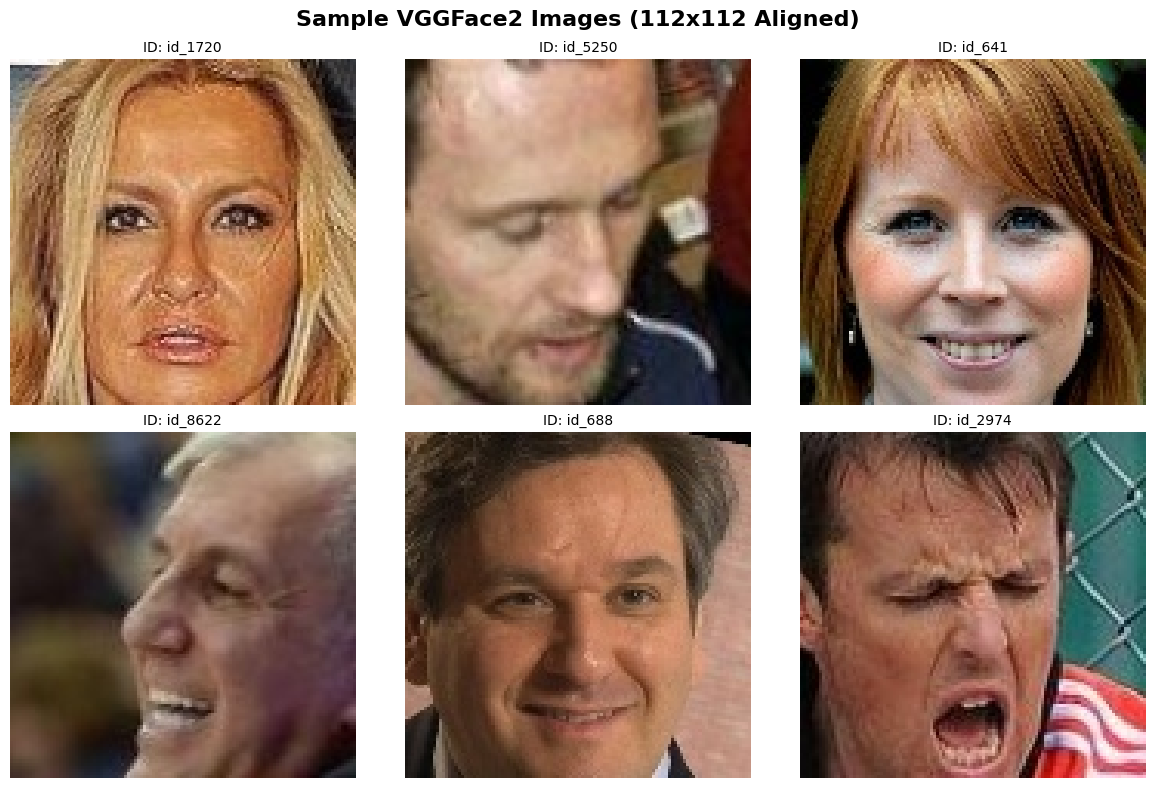


✅ VGGFace2 dataset is ready for training!

📊 Dataset Summary:
   • Training: ~7767 identities
   • Total images: ~3.14 million faces
   • Format: 112x112 RGB, pre-aligned

📚 Next steps:
   1. Model Architecture - MobileFaceNet + ArcFace
   2. Training Setup - Optimizer, scheduler, loss
   3. Model Training - Train on VGGFace2
   4. Evaluation - Test model performance
   5. Export - Save model for deployment


In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Select random identities from training set
train_identities = [d for d in TRAIN_DIR.iterdir() if d.is_dir()]
num_samples = min(6, len(train_identities))

if num_samples == 0:
    print("⚠️  No training identities found for visualization")
else:
    selected_identities = random.sample(train_identities, num_samples)

    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle('Sample VGGFace2 Images (112x112 Aligned)', fontsize=16, fontweight='bold')

    for idx, identity_dir in enumerate(selected_identities):
        # Get first image from this identity
        images = (list(identity_dir.glob("*.jpg")) +
                 list(identity_dir.glob("*.jpeg")) +
                 list(identity_dir.glob("*.png")))

        if images:
            img = Image.open(images[0])

            row = idx // 3
            col = idx % 3
            axes[row, col].imshow(img)

            # Show identity ID (truncate if too long)
            identity_name = identity_dir.name
            if len(identity_name) > 15:
                identity_name = identity_name[:15] + "..."
            axes[row, col].set_title(f'ID: {identity_name}', fontsize=10)
            axes[row, col].axis('off')
        else:
            # No images found
            row = idx // 3
            col = idx % 3
            axes[row, col].text(0.5, 0.5, 'No images',
                               ha='center', va='center')
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n✅ VGGFace2 dataset is ready for training!")
    print(f"\n📊 Dataset Summary:")
    print(f"   • Training: ~{len(train_identities)} identities")
    print(f"   • Total images: ~3.14 million faces")
    print(f"   • Format: 112x112 RGB, pre-aligned")
    print(f"\n📚 Next steps:")
    print(f"   1. Model Architecture - MobileFaceNet + ArcFace")
    print(f"   2. Training Setup - Optimizer, scheduler, loss")
    print(f"   3. Model Training - Train on VGGFace2")
    print(f"   4. Evaluation - Test model performance")
    print(f"   5. Export - Save model for deployment")